In [ ]:
!pip install torch torchvision

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import DataLoader

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class EncoderBackbone(nn.Module):
    def __init__(self):
        super(EncoderBackbone, self).__init__()

        self.encoder = models.resnet18(pretrained=False)
        self.encoder.fc = nn.Identity()  # remove classification layer

    def forward(self, x):
        features = self.encoder(x)  # Output: [batch_size, 512]
        return features

In [ ]:
class ReconstructionDecoder(nn.Module):
    def __init__(self, feature_dim=512):
        super(ReconstructionDecoder, self).__init__()

        self.decoder = nn.Sequential(
            nn.Linear(feature_dim, 8*8*128),
            nn.ReLU(),
            nn.Unflatten(1, (128, 8, 8)),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, features):
        return self.decoder(features)

In [ ]:
class MorphologyHead(nn.Module):
    def __init__(self, feature_dim=512):
        super(MorphologyHead, self).__init__()

        self.head = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 5)  # count, area, circularity, density, fractal
        )

    def forward(self, features):
        return self.head(features)

In [ ]:
class FormulationHead(nn.Module):
    def __init__(self, feature_dim=512):
        super(FormulationHead, self).__init__()

        self.head = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 4)  # diffusion, transport, bioavailability, efficacy
        )

    def forward(self, features):
        return self.head(features)

In [ ]:
class NanoBioHead(nn.Module):
    def __init__(self, feature_dim=512):
        super(NanoBioHead, self).__init__()

        self.head = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 3)  # membrane interaction, toxicity, zeta
        )

    def forward(self, features):
        return self.head(features)

In [ ]:
class ScreeningHead(nn.Module):
    def __init__(self, feature_dim=512):
        super(ScreeningHead, self).__init__()

        self.head = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, features):
        return self.head(features)

In [ ]:
class NanoVisionNetX(nn.Module):
    def __init__(self):
        super(NanoVisionNetX, self).__init__()

        self.encoder = EncoderBackbone()
        self.decoder = ReconstructionDecoder()
        self.morphology_head = MorphologyHead()
        self.formulation_head = FormulationHead()
        self.nanobio_head = NanoBioHead()
        self.screening_head = ScreeningHead()

    def forward(self, x):

        features = self.encoder(x)

        reconstruction = self.decoder(features)
        morphology = self.morphology_head(features)
        formulation = self.formulation_head(features)
        nanobio = self.nanobio_head(features)
        screening = self.screening_head(features)

        return {
            "reconstruction": reconstruction,
            "morphology": morphology,
            "formulation": formulation,
            "nanobio": nanobio,
            "screening": screening
        }

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NanoVisionNetX().to(DEVICE)

dummy_input = torch.randn(2, 3, 256, 256).to(DEVICE)

outputs = model(dummy_input)

for key, value in outputs.items():
    print(key, value.shape)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


reconstruction torch.Size([2, 3, 64, 64])
morphology torch.Size([2, 5])
formulation torch.Size([2, 4])
nanobio torch.Size([2, 3])
screening torch.Size([2, 1])


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NanoVisionNetX().to(DEVICE)
print("NanoVisionNet-X Loaded")

NanoVisionNet-X Loaded


In [ ]:
dummy_input = torch.randn(2, 3, 256, 256).to(DEVICE)

outputs = model(dummy_input)

for key in outputs:
    print(key, outputs[key].shape)

reconstruction torch.Size([2, 3, 64, 64])
morphology torch.Size([2, 5])
formulation torch.Size([2, 4])
nanobio torch.Size([2, 3])
screening torch.Size([2, 1])


In [ ]:
recon_loss = nn.MSELoss()
reg_loss = nn.MSELoss()
bce_loss = nn.BCELoss()

In [ ]:
!git clone https://github.com/Charith003/nu_data.git

Cloning into 'nu_data'...
remote: Enumerating objects: 8441, done.
remote: Total 8441 (delta 0), reused 0 (delta 0), pack-reused 8441 (from 1)
Receiving objects: 100% (8441/8441), 199.34 MiB | 25.33 MiB/s, done.
Resolving deltas: 100% (433/433), done.
Updating files: 100% (8427/8427), done.


In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

class SimpleNucleiDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        self.transform = transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor()
        ])

        for sample_id in os.listdir(root_dir):
            sample_path = os.path.join(root_dir, sample_id)

            if os.path.isdir(sample_path):
                image_folder = os.path.join(sample_path, "images")

                if os.path.exists(image_folder):
                    image_file = os.listdir(image_folder)[0]
                    self.samples.append(
                        os.path.join(image_folder, image_file)
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image = Image.open(self.samples[idx]).convert("RGB")
        image = self.transform(image)
        return image, 0

In [ ]:
import os

TRAIN_FOLDER = "/content/nu_data/stage_1_train"

print(os.listdir(TRAIN_FOLDER)[:10])

['2e172afb1f43b359f1f0208da9386aefe97c0c1afe202abfe6ec09cdca820990.jpg', 'a65bbfc5673e8053b6ce49f39c79cf3a846fe5cc46dd93105f74fb07cf44606d.jpg', '3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f929b9.jpg', '0402a81e75262469925ea893b6706183832e85324f7b1e08e634129f5d522cdd.jpg', '55f98f43c152aa0dc8bea513f8ba558cc57494b81ae4ee816977816e79629c50.jpg', '60cb718759bff13f81c4055a7679e81326f78b6a193a2d856546097c949b20ff.jpg', '1e61ecf354cb93a62a9561db87a53985fb54e001444f98112ed0fc623fad793e.jpg', 'da5f98f2b8a64eee735a398de48ed42cd31bf17a6063db46a9e0783ac13cd844.jpg', '7c318172e976ae5a962c9c7a4e9fe46d7fb985765ddd3a3e2108e893a90b92b2.jpg', 'a7f767ca9770b160f234780e172aeb35a50830ba10dc49c526f4712451abe1d2.jpg']


In [ ]:
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import os

class SimpleNucleiDataset(Dataset):
    def __init__(self, root_dir):
        self.image_paths = []

        self.transform = transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor()
        ])

        for file in os.listdir(root_dir):
            if file.endswith((".jpg", ".png", ".jpeg")):
                self.image_paths.append(os.path.join(root_dir, file))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        image = self.transform(image)
        return image, 0

In [ ]:
from torch.utils.data import DataLoader

TRAIN_FOLDER = "/content/nu_data/stage_1_train"

train_dataset = SimpleNucleiDataset(TRAIN_FOLDER)

print("Total training samples:", len(train_dataset))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

Total training samples: 664


In [ ]:
from torch.utils.data import DataLoader

TRAIN_FOLDER = "/content/nu_data/stage_1_train"

train_dataset = SimpleNucleiDataset(TRAIN_FOLDER)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

print("Total training samples:", len(train_dataset))

Total training samples: 664


In [ ]:
recon_loss = nn.MSELoss()
reg_loss = nn.MSELoss()

In [ ]:
class ReconstructionDecoder(nn.Module):
    def __init__(self, feature_dim=512):
        super(ReconstructionDecoder, self).__init__()

        self.decoder = nn.Sequential(
            nn.Linear(feature_dim, 8*8*256),
            nn.ReLU(),
            nn.Unflatten(1, (256, 8, 8)),

            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 16x16
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 32x32
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),    # 64x64
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),    # 128x128
            nn.ReLU(),

            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1),     # 256x256
            nn.Sigmoid()
        )

    def forward(self, features):
        return self.decoder(features)

In [ ]:
dummy = torch.randn(2,3,256,256).to(DEVICE)
out = model(dummy)

print("Input shape:", dummy.shape)
print("Reconstruction shape:", out["reconstruction"].shape)

Input shape: torch.Size([2, 3, 256, 256])
Reconstruction shape: torch.Size([2, 3, 64, 64])


In [ ]:
class ReconstructionDecoder(nn.Module):
    def __init__(self, feature_dim=512):
        super().__init__()

        self.decoder = nn.Sequential(
            nn.Linear(feature_dim, 8*8*256),
            nn.ReLU(),
            nn.Unflatten(1, (256, 8, 8)),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 16
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 32
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 64
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, 4, 2, 1),    # 128
            nn.ReLU(),

            nn.ConvTranspose2d(16, 3, 4, 2, 1),     # 256
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(x)

In [ ]:
model = NanoVisionNetX().to(DEVICE)

In [ ]:
dummy = torch.randn(2,3,256,256).to(DEVICE)
out = model(dummy)

print(out["reconstruction"].shape)

torch.Size([2, 3, 256, 256])


In [ ]:
loss_recon = recon_loss(
    F.interpolate(outputs["reconstruction"], size=(256,256)),
    images
)

In [ ]:
images, _ = next(iter(train_loader))
images = images.to(DEVICE)

outputs = model(images)

print("Input:", images.shape)
print("Reconstruction:", outputs["reconstruction"].shape)

Input: torch.Size([4, 3, 256, 256])
Reconstruction: torch.Size([4, 3, 256, 256])


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for images, _ in train_loader:

    images = images.to(DEVICE)

    outputs = model(images)

    loss_recon = recon_loss(outputs["reconstruction"], images)

    dummy_target = torch.randn(images.size(0), 5).to(DEVICE)
    loss_morph = reg_loss(outputs["morphology"], dummy_target)

    loss = loss_recon + 0.5 * loss_morph

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print("Loss:", loss.item())
    break

Loss: 0.8221973180770874


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for images, _ in train_loader:

    images = images.to(DEVICE)

    outputs = model(images)

    # Reconstruction loss
    loss_recon = recon_loss(outputs["reconstruction"], images)

    # Dummy regression targets (replace with real values later)
    dummy_target = torch.randn(images.size(0), 5).to(DEVICE)
    loss_morph = reg_loss(outputs["morphology"], dummy_target)

    loss = loss_recon + 0.5 * loss_morph

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print("Loss:", loss.item())
    break

Loss: 0.6490830183029175


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NanoVisionNetX().to(DEVICE)
model.eval()

NanoVisionNetX(
  (encoder): EncoderBackbone(
    (encoder): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (

In [ ]:
import os

TRAIN_FOLDER = "/content/nu_data/stage_1_train"

image_files = [f for f in os.listdir(TRAIN_FOLDER)
               if f.endswith((".jpg", ".png", ".jpeg"))]

sample_path = os.path.join(TRAIN_FOLDER, image_files[0])

print("Using sample:", sample_path)

Using sample: /content/nu_data/stage_1_train/2e172afb1f43b359f1f0208da9386aefe97c0c1afe202abfe6ec09cdca820990.jpg


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NanoVisionNetX().to(DEVICE)
model.eval()

NanoVisionNetX(
  (encoder): EncoderBackbone(
    (encoder): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (

In [ ]:
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

image = Image.open(sample_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(DEVICE)

print("Input shape:", input_tensor.shape)

Input shape: torch.Size([1, 3, 256, 256])


In [ ]:
with torch.no_grad():
    outputs = model(input_tensor)

In [ ]:
reconstruction = outputs["reconstruction"]
morphology = outputs["morphology"]
formulation = outputs["formulation"]
nanobio = outputs["nanobio"]
screening = outputs["screening"]

In [ ]:
print("Morphology Metrics:", morphology.cpu().numpy())
print("Formulation Metrics:", formulation.cpu().numpy())
print("NanoBio Metrics:", nanobio.cpu().numpy())
print("Screening Risk Score:", screening.item())

Morphology Metrics: [[ 0.04478189  0.06161268 -0.06818739 -0.10901796  0.08515443]]
Formulation Metrics: [[ 0.04474335 -0.11221148  0.00781497  0.05160902]]
NanoBio Metrics: [[-0.01530978  0.0360686  -0.06622204]]
Screening Risk Score: 0.4958014190196991


In [ ]:
class NanoVisionNetX(nn.Module):
    def __init__(self):
        super(NanoVisionNetX, self).__init__()

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class NanoVisionNetX(nn.Module):
    def __init__(self):
        super(NanoVisionNetX, self).__init__()

        # ✅ Pretrained ResNet Encoder
        self.encoder = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )
        self.encoder.fc = nn.Identity()

        feature_dim = 512

        # ✅ Fixed 256x256 Decoder
        self.decoder = nn.Sequential(
            nn.Linear(feature_dim, 8*8*256),
            nn.ReLU(),
            nn.Unflatten(1, (256, 8, 8)),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 16
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 32
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 64
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, 4, 2, 1),    # 128
            nn.ReLU(),

            nn.ConvTranspose2d(16, 3, 4, 2, 1),     # 256
            nn.Sigmoid()
        )

        # Morphology head
        self.morphology_head = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 5)
        )

        # Formulation head
        self.formulation_head = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )

        # NanoBio head
        self.nanobio_head = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

        # Screening head
        self.screening_head = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.encoder(x)

        reconstruction = self.decoder(features)
        morphology = self.morphology_head(features)
        formulation = self.formulation_head(features)
        nanobio = self.nanobio_head(features)
        screening = self.screening_head(features)

        return {
            "reconstruction": reconstruction,
            "morphology": morphology,
            "formulation": formulation,
            "nanobio": nanobio,
            "screening": screening
        }

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NanoVisionNetX().to(DEVICE)

In [ ]:
dummy = torch.randn(2,3,256,256).to(DEVICE)
out = model(dummy)
print(out["reconstruction"].shape)

torch.Size([2, 3, 256, 256])


In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(DEVICE)

        outputs = model(images)

        loss_recon = recon_loss(outputs["reconstruction"], images)

        optimizer.zero_grad()
        loss_recon.backward()
        optimizer.step()

        total_loss += loss_recon.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.1902
Epoch 2, Loss: 0.1902
Epoch 3, Loss: 0.1902
Epoch 4, Loss: 0.1902
Epoch 5, Loss: 0.1902
Epoch 6, Loss: 0.1902
Epoch 7, Loss: 0.1902
Epoch 8, Loss: 0.1902
Epoch 9, Loss: 0.1902
Epoch 10, Loss: 0.1902


In [ ]:
recon_loss = nn.MSELoss()

In [ ]:
recon_loss = nn.L1Loss()

In [ ]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
print("Reconstruction min:", reconstruction.min().item())
print("Reconstruction max:", reconstruction.max().item())

Reconstruction min: 0.46942296624183655
Reconstruction max: 0.5309854745864868


In [ ]:
EPOCHS = 8

for epoch in range(EPOCHS):
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(DEVICE)

        outputs = model(images)
        loss = recon_loss(outputs["reconstruction"], images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.4199
Epoch 2, Loss: 0.4199
Epoch 3, Loss: 0.4199
Epoch 4, Loss: 0.4199
Epoch 5, Loss: 0.4199
Epoch 6, Loss: 0.4199
Epoch 7, Loss: 0.4199
Epoch 8, Loss: 0.4199


In [ ]:
recon_loss = nn.L1Loss()

In [ ]:
weights=models.ResNet18_Weights.IMAGENET1K_V1

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving jw-2h 1_(c1+c5).TIF.jpg to jw-2h 1_(c1+c5).TIF.jpg


In [ ]:
image_path = list(uploaded.keys())[0]
print("Loaded file:", image_path)

Loaded file: jw-2h 1_(c1+c5).TIF.jpg


In [ ]:
from PIL import Image
from torchvision import transforms
import torch

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(DEVICE)

print("Input shape:", input_tensor.shape)

Input shape: torch.Size([1, 3, 256, 256])


In [ ]:
model.eval()

with torch.no_grad():
    outputs = model(input_tensor)

reconstruction = outputs["reconstruction"]

In [ ]:
print("Reconstruction Min:", reconstruction.min().item())
print("Reconstruction Max:", reconstruction.max().item())
print("Reconstruction Mean:", reconstruction.mean().item())

Reconstruction Min: 0.4855089485645294
Reconstruction Max: 0.5338766574859619
Reconstruction Mean: 0.5146449208259583


In [ ]:
single_image = input_tensor.clone()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
recon_loss = nn.L1Loss()

for i in range(500):
    outputs = model(single_image)
    loss = recon_loss(outputs["reconstruction"], single_image)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 50 == 0:
        print("Step:", i, "Loss:", loss.item())

Step: 0 Loss: 0.32967740297317505
Step: 50 Loss: 0.07208087295293808
Step: 100 Loss: 0.05975883826613426
Step: 150 Loss: 0.052546337246894836
Step: 200 Loss: 0.03936487063765526
Step: 250 Loss: 0.029492909088730812
Step: 300 Loss: 0.019101785495877266
Step: 350 Loss: 0.0177003163844347
Step: 400 Loss: 0.01751003973186016
Step: 450 Loss: 0.014738690108060837


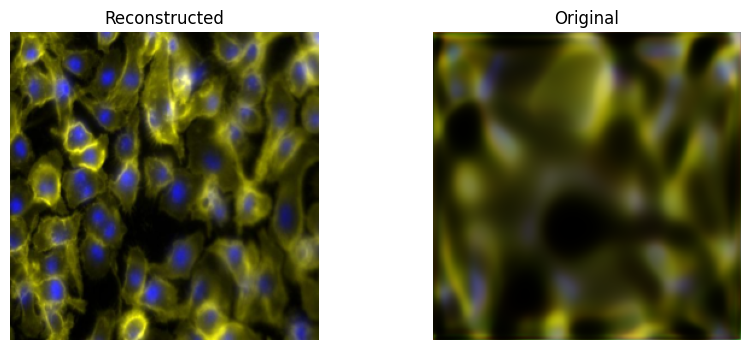

In [ ]:
with torch.no_grad():
    outputs = model(single_image)

recon = outputs["reconstruction"][0].cpu().permute(1,2,0).numpy()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Reconstructed")
plt.imshow(single_image[0].cpu().permute(1,2,0))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Original")
plt.imshow(recon)
plt.axis("off")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

In [ ]:
class NanoVisionNetX(nn.Module):
    def __init__(self):
        super(NanoVisionNetX, self).__init__()

        # ----------------------------
        # ResNet18 Encoder (Spatial)
        # ----------------------------
        resnet = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )

        self.encoder = nn.Sequential(
            resnet.conv1,    # 64
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,   # 64
            resnet.layer2,   # 128
            resnet.layer3,   # 256
            resnet.layer4    # 512
        )

        # Output shape: [B, 512, 8, 8] for 256x256 input

        # ----------------------------
        # U-Net Style Decoder
        # ----------------------------
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 32x32
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 64x64
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),    # 128x128
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),     # 256x256
            nn.Sigmoid()
        )

        # ----------------------------
        # Global Feature Vector
        # ----------------------------
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))

        feature_dim = 512

        # ----------------------------
        # Morphology Head
        # ----------------------------
        self.morphology_head = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 5)  # count, area, circularity, density, fractal
        )

        # ----------------------------
        # Formulation Head
        # ----------------------------
        self.formulation_head = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 4)  # diffusion, transport, bioavailability, efficacy
        )

        # ----------------------------
        # NanoBio Head
        # ----------------------------
        self.nanobio_head = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 3)  # membrane, toxicity, zeta
        )

        # ----------------------------
        # Screening Head
        # ----------------------------
        self.screening_head = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):

        # Encode
        features_map = self.encoder(x)          # [B,512,8,8]

        # Reconstruction
        reconstruction = self.decoder(features_map)

        # Global feature vector
        pooled = self.global_pool(features_map)
        pooled = pooled.view(pooled.size(0), -1)  # [B,512]

        # Multi-task heads
        morphology = self.morphology_head(pooled)
        formulation = self.formulation_head(pooled)
        nanobio = self.nanobio_head(pooled)
        screening = self.screening_head(pooled)

        return {
            "reconstruction": reconstruction,
            "morphology": morphology,
            "formulation": formulation,
            "nanobio": nanobio,
            "screening": screening
        }

In [ ]:
class NanoVisionNetX(nn.Module):
    def __init__(self):
        super(NanoVisionNetX, self).__init__()

        # ----------------------------
        # ResNet18 Encoder (Spatial)
        # ----------------------------
        resnet = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )

        self.encoder = nn.Sequential(
            resnet.conv1,    # 64
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,   # 64
            resnet.layer2,   # 128
            resnet.layer3,   # 256
            resnet.layer4    # 512
        )

        # Output shape: [B, 512, 8, 8] for 256x256 input

        # ----------------------------
        # U-Net Style Decoder
        # ----------------------------
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 32x32
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 64x64
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),    # 128x128
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),     # 256x256
            nn.Sigmoid()
        )

        # ----------------------------
        # Global Feature Vector
        # ----------------------------
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))

        feature_dim = 512

        # ----------------------------
        # Morphology Head
        # ----------------------------
        self.morphology_head = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 5)  # count, area, circularity, density, fractal
        )

        # ----------------------------
        # Formulation Head
        # ----------------------------
        self.formulation_head = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 4)  # diffusion, transport, bioavailability, efficacy
        )

        # ----------------------------
        # NanoBio Head
        # ----------------------------
        self.nanobio_head = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 3)  # membrane, toxicity, zeta
        )

        # ----------------------------
        # Screening Head
        # ----------------------------
        self.screening_head = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):

        # Encode
        features_map = self.encoder(x)          # [B,512,8,8]

        # Reconstruction
        reconstruction = self.decoder(features_map)

        # Global feature vector
        pooled = self.global_pool(features_map)
        pooled = pooled.view(pooled.size(0), -1)  # [B,512]

        # Multi-task heads
        morphology = self.morphology_head(pooled)
        formulation = self.formulation_head(pooled)
        nanobio = self.nanobio_head(pooled)
        screening = self.screening_head(pooled)

        return {
            "reconstruction": reconstruction,
            "morphology": morphology,
            "formulation": formulation,
            "nanobio": nanobio,
            "screening": screening
        }

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NanoVisionNetX().to(DEVICE)
print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.L1Loss()

single_image = input_tensor.clone().to(DEVICE)

for i in range(300):
    outputs = model(single_image)
    loss = criterion(outputs["reconstruction"], single_image)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 50 == 0:
        print("Step:", i, "Loss:", loss.item())

Step: 0 Loss: 0.31077924370765686
Step: 50 Loss: 0.21313321590423584
Step: 100 Loss: 0.15972717106342316
Step: 150 Loss: 0.12124273926019669
Step: 200 Loss: 0.09303424507379532
Step: 250 Loss: 0.07242324203252792


In [ ]:
import os
from pathlib import Path

DATASET_PATH = Path("nu_data")  # change if needed

print("Folders in dataset:")
print(os.listdir(DATASET_PATH))

Folders in dataset:
['BBBC018', 'stage_1_train', 'TNBC_NucleiSegmentation', 'BBBC007', 'BBBC006', 'nuclei_partial_annotations', '2009_ISBI_2DNuclei', 'BBBC020', 'color_wikipedia', 'cluster_nuclei', 'stage_2_test', 'stage_1_test', '.git']


In [ ]:
import glob

jpg_files = glob.glob("nu_data/**/*.jpg", recursive=True)
png_files = glob.glob("nu_data/**/*.png", recursive=True)

print("JPG count:", len(jpg_files))
print("PNG count:", len(png_files))

JPG count: 8420
PNG count: 1


In [ ]:
from PIL import Image
import numpy as np

sizes = []

for img_path in jpg_files[:200]:  # limit for speed
    img = Image.open(img_path)
    sizes.append(img.size)

sizes = np.array(sizes)

print("Average Width:", sizes[:,0].mean())
print("Average Height:", sizes[:,1].mean())

Average Width: 412.03
Average Height: 382.12


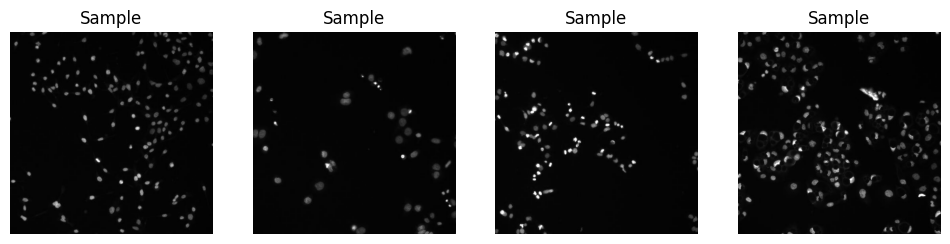

In [ ]:
import matplotlib.pyplot as plt

sample_imgs = jpg_files[:4]

plt.figure(figsize=(12,6))

for i, img_path in enumerate(sample_imgs):
    img = Image.open(img_path)
    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title("Sample")
    plt.axis("off")

plt.show()

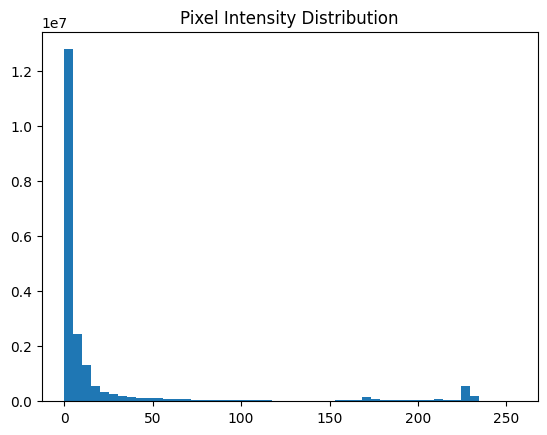

In [ ]:
all_pixels = []

for img_path in jpg_files[:100]:
    img = np.array(Image.open(img_path).convert("L"))
    all_pixels.extend(img.flatten())

plt.hist(all_pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

In [ ]:
mask_files = glob.glob("nu_data/**/*.png", recursive=True)

unique_values = set()

for m in mask_files[:100]:
    mask = np.array(Image.open(m))
    unique_values.update(np.unique(mask))

print("Unique mask values:", unique_values)

Unique mask values: {np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20), np.uint8(21), np.uint8(22), np.uint8(23), np.uint8(24), np.uint8(25), np.uint8(26), np.uint8(27), np.uint8(28), np.uint8(29), np.uint8(30), np.uint8(31), np.uint8(32), np.uint8(33), np.uint8(34), np.uint8(35), np.uint8(36), np.uint8(37), np.uint8(38), np.uint8(39), np.uint8(40), np.uint8(41), np.uint8(42), np.uint8(43), np.uint8(44), np.uint8(45), np.uint8(46), np.uint8(47), np.uint8(48), np.uint8(49), np.uint8(50), np.uint8(51), np.uint8(52), np.uint8(53), np.uint8(54), np.uint8(55), np.uint8(56), np.uint8(57), np.uint8(58), np.uint8(59), np.uint8(60), np.uint8(61), np.uint8(62), np.uint8(63), np.uint8(64), np.uint8(65), np.uint8(66), np.uint8(67), np.uint8(68), np.uint8(69), np.uint8(

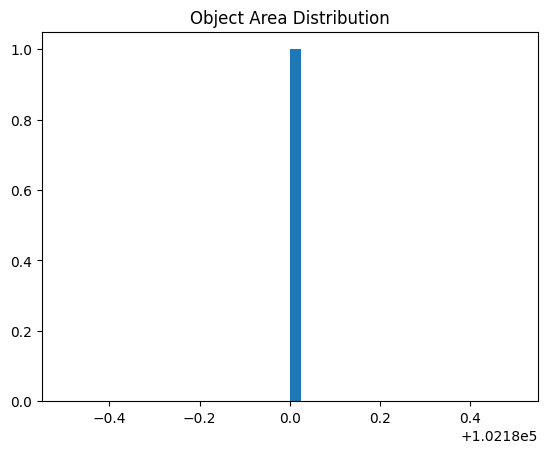

In [ ]:
import cv2

areas = []

for m in mask_files[:100]:
    mask = cv2.imread(m, 0)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for c in contours:
        area = cv2.contourArea(c)
        areas.append(area)

plt.hist(areas, bins=40)
plt.title("Object Area Distribution")
plt.show()

In [ ]:
print("Train images:", len(glob.glob("nu_data/stage_1_train/*.jpg")))
print("Test images:", len(glob.glob("nu_data/stage_1_test/*.jpg")))

Train images: 664
Test images: 65
